## 1. Problem Understanding

### Problem Statement
The US experiences a high volume of traffic accidents each year, leading to significant economic, societal, and personal costs. Understanding the patterns, causes, and impacts of these accidents is crucial for improving road safety and infrastructure. The goal of this analysis is to explore the historical traffic accident dataset to identify key factors—such as weather conditions, time, and geographic location—that contribute to the frequency and severity of accidents.

### Analytical Questions
1. **Weather Impact**: How do different weather conditions (e.g., rain, snow, fog) and specific weather metrics (temperature, visibility) impact the severity of traffic accidents?
2. **Temporal Patterns**: What are the temporal patterns of accidents? Are there specific months, days, or times of day when accidents are more frequent or more severe?
3. **Geographic Distribution**: Which states or cities experience the highest frequency of accidents, and how does accident severity vary geographically?


In [11]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Needed Functions for data cleaning:

In [12]:
def drop_duplicates(data):
    # Drop duplicate rows to reduce memory usage and improve performance.
    data.drop_duplicates(inplace=True)
    print("Duplicates dropped.")
    return data

In [13]:
def drop_columns(data):
    # Drop unneeded columns that aren't useful for our model
    cols = [
    "Description",
    "ID",
    "Source",
    "Zipcode",
    "Timezone",
    "Country",
    "Astronomical_Twilight",
    "Nautical_Twilight",
    "Civil_Twilight",
    "End_Lat",
    "End_Lng"
    ]
    data = data.drop(columns = cols, errors='ignore')
    print("Unuseful columns dropped.")
    return data


In [14]:
def fix_datatypes(data):
    # Fixes Time data types 
    data['Start_Time'] = pd.to_datetime(data['Start_Time'], format='mixed')
    data['End_Time']   = pd.to_datetime(data['End_Time'], format='mixed')

    # Extract year, month, day and hour for better analysis
    data['start_year'] = data['Start_Time'].dt.year
    data['start_month'] = data['Start_Time'].dt.month
    data['start_day'] = data['Start_Time'].dt.day
    data['start_hour'] = data['Start_Time'].dt.hour

    print("Time datatype fixing and extraction finished.")
    return(data)

In [15]:
def filter_year(data, start_year=2020):
    # Filters the dataset to include specified years
    # To only focus on recent data
    data = data[data['Start_Time'].dt.year >= 2020]
    print(f"Filtering starting from year {start_year} finished")
    return data

In [16]:
def get_monthly_data(data):
    data['year_month'] = data['Start_Time'].dt.to_period('M')

    data_monthly = data.groupby('year_month').agg({
        'Severity': 'mean',
        'Distance(mi)': 'mean',
        'Start_Lat': 'mean',
        'Start_Lng': 'mean'
    }).reset_index()

    data_monthly['accident_count'] = data.groupby('year_month').size().values
    print(df_monthly.head())

In [17]:
def get_daily_data(data):
    df['day_date'] = df['Start_Time'].dt.to_period('D')
    df_daily = df.groupby('day_date').agg({
        'Severity': 'mean',
        'Distance(mi)': 'mean',
        'Start_Lat': 'mean',
        'Start_Lng': 'mean'
    }).reset_index()
    df_daily['accident_count'] = df.groupby('day_date').size().values
    print(df_daily.head(1000))

In [18]:
def handle_missing_values(data):
    # 1. Handle missing numerical values
    num_cols = ['Temperature(F)',
        'Humidity(%)',
        'Pressure(in)',
        'Visibility(mi)',
        'Wind_Speed(mph)',
        'Wind_Chill(F)',
        ]
    for i in num_cols:
        # Fill missing values using median values grouped by Airport_Code and City
        # This preserves local weather patterns since each airport represents a specific weather station
        medians = data.groupby(['Airport_Code','State'])[i].transform('median')
        data[i] = data[i].fillna(medians)
        # For any remaining missing values, fill with the overall median
        data[i] = data[i].fillna(data[i].median())
    
    # 2.Handle Wind_Direction
    # As zero wind speed means no movement of air so we considered wind direction is "calm"
    data.loc[(data['Wind_Direction'].isna()) & (data['Wind_Speed(mph)'] == 0), 'Wind_Direction'] = "Calm"
    # Fill missing Wind_Direction using mode grouped by Airport_Code & State
    data['Wind_Direction'] = data['Wind_Direction'].fillna(data.groupby(['Airport_Code','State'])['Wind_Direction']
        .transform(lambda x: x.mode()[0] if not x.mode().empty else None))
    # Fill any remaining missings with global mode
    data["Wind_Direction"] = data["Wind_Direction"].fillna(data["Wind_Direction"].mode()[0])

    # Airport_Code isn't usefull anymore
    data.drop('Airport_Code', axis=1, inplace=True)

    # 3.Handle Sunrise_Sunset
    # Fill missing values in sunrise_sunset using mode grouped by start_hour 
    #To reflect time & location patterns
    data["Sunrise_Sunset"] = data["Sunrise_Sunset"].fillna(data.groupby("start_hour")["Sunrise_Sunset"]
        .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None))

    # 4.Handle Precipitation(in)
    # Fill missing precipitation values with 0 under the assumption that NaN represents no recorded rainfall
    data["Precipitation(in)"]=data["Precipitation(in)"].fillna(0)

    # 5.Handle weather condition
    # Replace missing weather values with a placeholder
    data['Weather_Condition'] = data['Weather_Condition'].fillna('Missing')

    # Identify the 8 most frequent weather conditions in the dataset
    top_weather = data['Weather_Condition'].value_counts().nlargest(8).index

    # Keep only the top weather conditions and group all others into "Other"
    data['Weather_Condition'] = data['Weather_Condition'].where(
        data['Weather_Condition'].isin(top_weather),
        'Other'
    )

    print("Missing values handled")
    return data


In [19]:
def handle_outliers(data):
    # Handling outliers in Temperature(F) , Wind_Chill(F) & Pressure(in) using the 95% empirical rule 
    CL = ["Temperature(F)", "Wind_Chill(F)","Pressure(in)"]

    # Get mean and standard deviation for each feature
    # Define lower and upper bounds assuming normal distribution and detect outliers outside these bounds 
    for col in CL:
        mean = data[col].mean()
        std = data[col].std()

        lower = mean - 1.96 * std
        upper = mean + 1.96 * std

        outliers = data[(data[col] < lower) | (data[col] > upper)]
        # Limit values to a defined statistical range for handling outliers
        data.loc[data[col] < lower, col] = lower
        data.loc[data[col] > upper, col] = upper

        
        print(f"Column: {col}")
        print(f"Mean: {mean:}")
        print(f"Std: {std:}")
        print(f"Lower bound (95%): {lower:}")
        print(f"Upper bound (95%): {upper:}")
        print(f"length of Outliers : {len(outliers)}\n")

    #Using the IQR method to detect outliers 
    lst= ["Humidity(%)","Wind_Speed(mph)","Visibility(mi)"]
    for i in lst:

        Q1 = data[i].quantile(0.25)
        Q3 = data[i].quantile(0.75)
        IQR = Q3 - Q1

        upper_whisker = Q3 + 1.5 * IQR
        lower_whisker = Q1 - 1.5 * IQR

        length_upper = len(data[data[i] > upper_whisker])
        length_lower = len(data[data[i] < lower_whisker])

        print("Column Name:", i)
        print(f"lower_whisker: {lower_whisker}")
        print(f"upper_whisker: {upper_whisker}")
        print(f"length of data above upper: {length_upper}")
        print(f"length of data below lower: {length_lower}\n")

        # Handle Visibility(mi) by constraining values to the range [0,10] 
        data.loc[data["Visibility(mi)"] < 0, "Visibility(mi)"] = 0
        data.loc[data["Visibility(mi)"] > 10, "Visibility(mi)"] = 10 
    
    print("Outliers are handled")
    return data
    

Taking alook at the data and start executing the functions

In [20]:
# Load the dataset
# df=pd.read_csv("/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv")
df = pd.read_csv("US_Accidents_March23.csv")

In [ ]:
print(f"Dataset Shape: {df.shape}")

Initial Dataset Shape: (7728394, 46)


In [22]:
print("Info:\n")
print(df.info())

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)

In [ ]:
print("Nulls count:\n")
print(df.isna().sum())


Duplicates count:

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                 

In [25]:
# start cleaning
df_cleaned = drop_columns(df)
df_cleaned = drop_duplicates(df_cleaned)
df_cleaned = fix_datatypes(df_cleaned)
df_cleaned = filter_year(df_cleaned)
df_cleaned = handle_missing_values(df_cleaned)

Unuseful columns dropped.
Duplicates dropped.
Time datatype fixing and extraction finished.
Filtering starting from year 2020 finished
Missing values handled


Handling outliers

In [26]:
print("Describtion:\n")
print(df.describe())

Describtion:

           Severity     Start_Lat     Start_Lng       End_Lat       End_Lng  \
count  7.728394e+06  7.728394e+06  7.728394e+06  4.325632e+06  4.325632e+06   
mean   2.212384e+00  3.620119e+01 -9.470255e+01  3.626183e+01 -9.572557e+01   
std    4.875313e-01  5.076079e+00  1.739176e+01  5.272905e+00  1.810793e+01   
min    1.000000e+00  2.455480e+01 -1.246238e+02  2.456601e+01 -1.245457e+02   
25%    2.000000e+00  3.339963e+01 -1.172194e+02  3.346207e+01 -1.177543e+02   
50%    2.000000e+00  3.582397e+01 -8.776662e+01  3.618349e+01 -8.802789e+01   
75%    2.000000e+00  4.008496e+01 -8.035368e+01  4.017892e+01 -8.024709e+01   
max    4.000000e+00  4.900220e+01 -6.711317e+01  4.907500e+01 -6.710924e+01   

       Distance(mi)  Temperature(F)  Wind_Chill(F)   Humidity(%)  \
count  7.728394e+06    7.564541e+06   5.729375e+06  7.554250e+06   
mean   5.618423e-01    6.166329e+01   5.825105e+01  6.483104e+01   
std    1.776811e+00    1.901365e+01   2.238983e+01  2.282097e+01   
mi

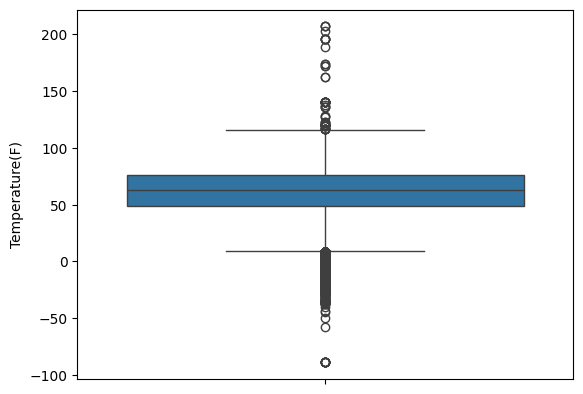

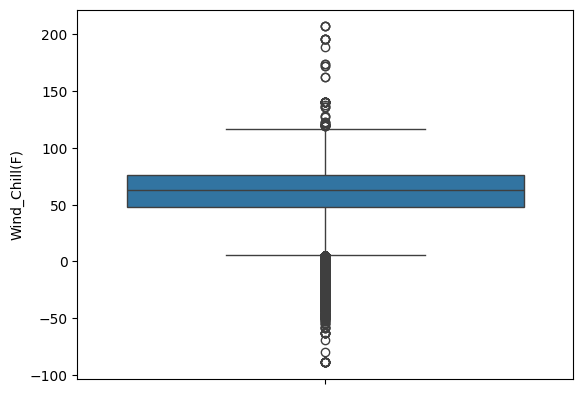

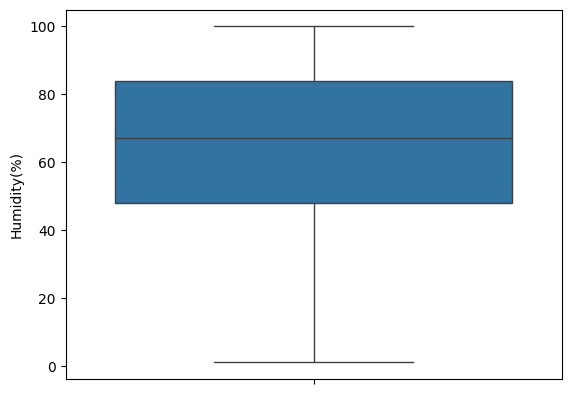

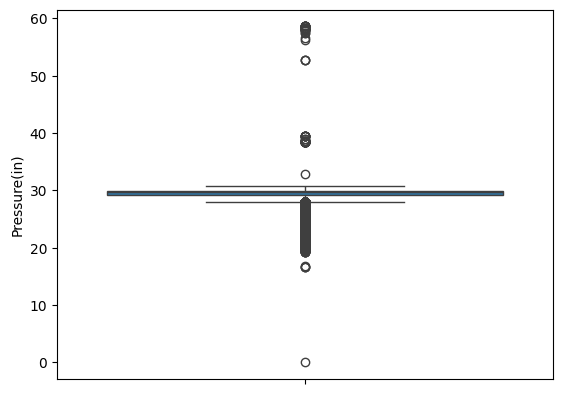

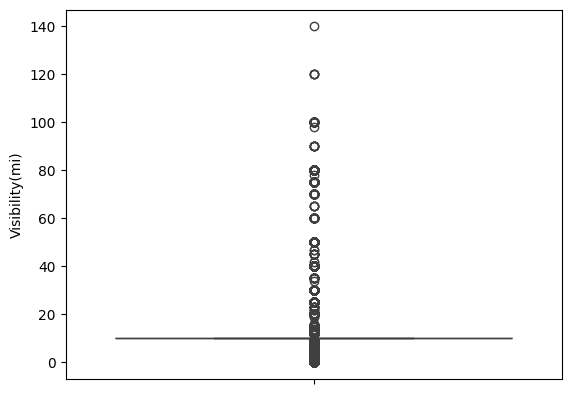

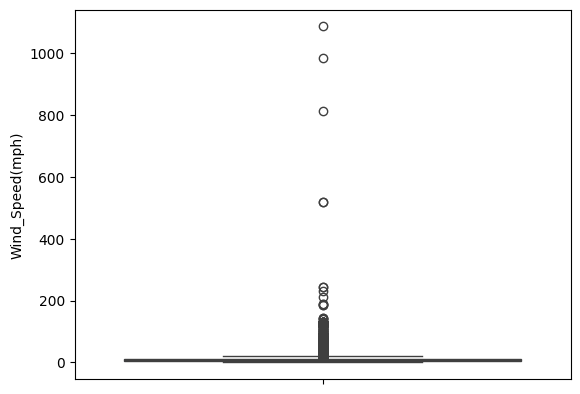

In [27]:
# Using boxplots to visually detect potential outliers in numerical weather-related features
cols= ["Temperature(F)","Wind_Chill(F)", "Humidity(%)" ,"Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)"]
for i in cols :
    sns.boxplot(df_cleaned[i])
    plt.show()

C:\Users\Al Shimaa\AppData\Local\Temp\ipykernel_26332\2950617081.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned[i])


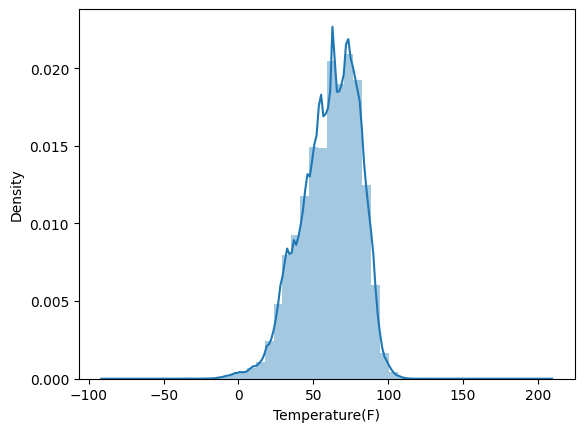

C:\Users\Al Shimaa\AppData\Local\Temp\ipykernel_26332\2950617081.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned[i])


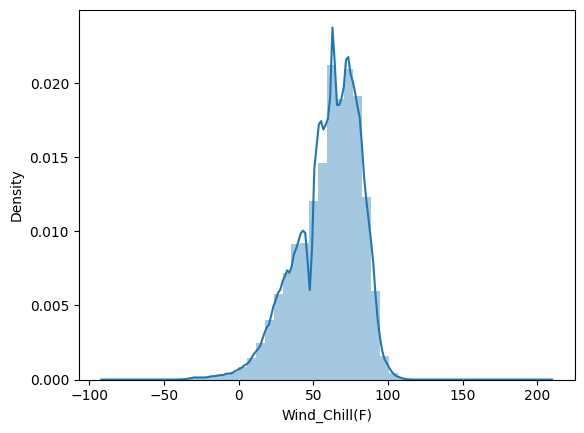

C:\Users\Al Shimaa\AppData\Local\Temp\ipykernel_26332\2950617081.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned[i])


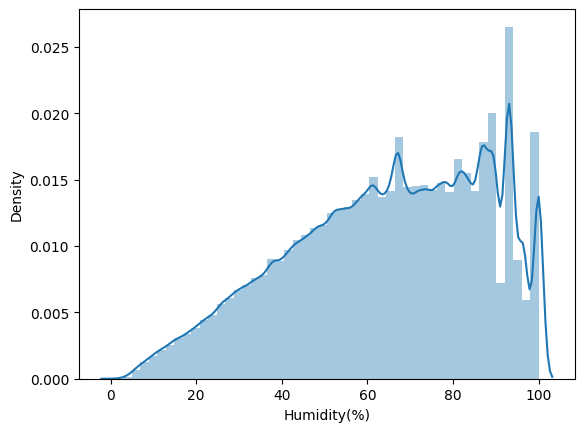

C:\Users\Al Shimaa\AppData\Local\Temp\ipykernel_26332\2950617081.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned[i])


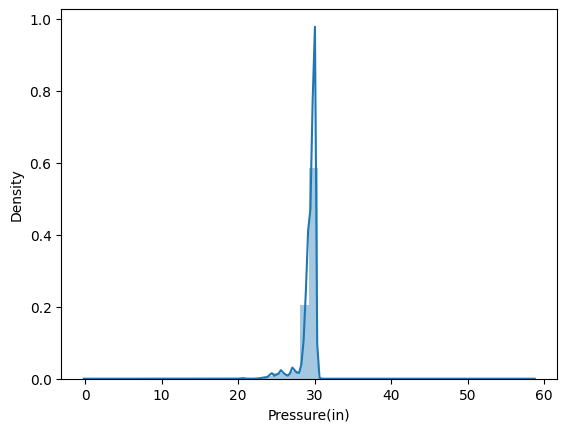

C:\Users\Al Shimaa\AppData\Local\Temp\ipykernel_26332\2950617081.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned[i])


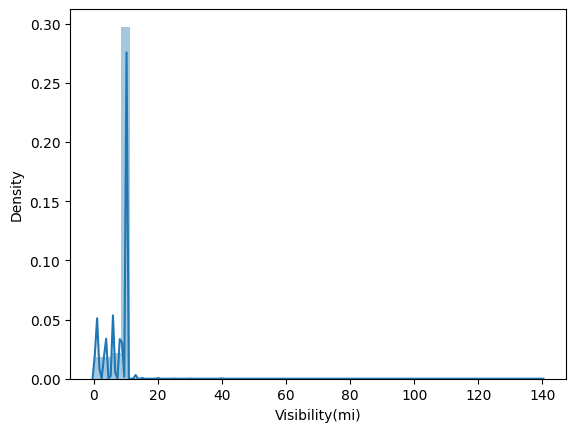

C:\Users\Al Shimaa\AppData\Local\Temp\ipykernel_26332\2950617081.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned[i])


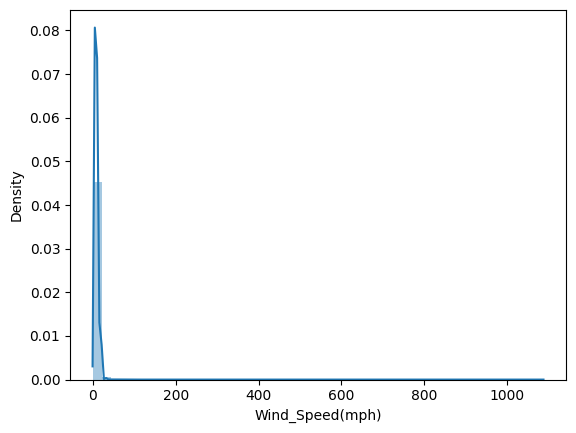

In [28]:
# Using distribution plots to analyze the shape of features
for i in cols :
    sns.distplot(df_cleaned[i])
    plt.show()

In [29]:
df_cleaned = handle_outliers(df_cleaned)

Column: Temperature(F)
Mean: 61.31740899622006
Std: 18.983286643884675
Lower bound (95%): 24.110167174206097
Upper bound (95%): 98.52465081823402
length of Outliers : 180659

Column: Wind_Chill(F)
Mean: 60.06319316960127
Std: 21.085972484415183
Lower bound (95%): 18.73468710014751
Upper bound (95%): 101.39169923905503
length of Outliers : 199335

Column: Pressure(in)
Mean: 29.35618479085125
Std: 1.10918171761596
Lower bound (95%): 27.182188624323967
Upper bound (95%): 31.53018095737853
length of Outliers : 244036

Column Name: Humidity(%)
lower_whisker: -6.0
upper_whisker: 138.0
length of data above upper: 0
length of data below lower: 0

Column Name: Wind_Speed(mph)
lower_whisker: -7.5
upper_whisker: 20.5
length of data above upper: 95396
length of data below lower: 0

Column Name: Visibility(mi)
lower_whisker: 10.0
upper_whisker: 10.0
length of data above upper: 0
length of data below lower: 871583

Outliers are handled


Export the cleaned dataset

In [ ]:
# out = "cleaned_dataset.csv"
# df_cleaned.to_csv(out, index=False)
# print("Data saved successfully.")

Data saved successfully.
